# Part 1 Khushi Gohel KKG786

#Section 1 - Introduction & Model Selection


I chose the Population Dynamics Model. Population Dynamics can model how a population behaves over time
with limited resources.
For example modeling predator prey systems, bacteria growth, and resource managements
could be possible real-world scenarios. The system that is being modeled is the increase of the population of the United States through time. Population dynamics is helpful since the population will not continue to increase at the same constant rate indefinitely. While initially the population increases quickly, due to the diminishing availability of resources, the population growth decreases.

The governing ODE:

$$
\frac{d^2P}{dt^2}=rP-kP^2
$$

- $P(t)$ is the population (millions)
- $t$ is time (years).
- $rP$ is the natural growth term
- $kP^2$ is the limiting term

Conversion to system of first-order ODE's:

$$
y_1=P
$$

$$
y_2=
\frac{dP}{dt}
$$

Then:

$$
\frac{dy_1}{dt}=y_2
$$

$$
\frac{dy_2}{dt}=ry_1-ky_1^2
$$

- $y_1$ is population
- $y_2$ is rate of change of population
- $r$ is the population growth coefficient
- $k$ is limiter

# Section 2 Parameter Research & Justification

The model is designed using the United States' population as of 2010. The initial number of population that I used is 308.309183463 million, and this figure represents the population of the United States at the time of the first census. For the purpose of growth coefficient $r$, I have chosen a value of 0.03 representing a moderate growth rate. As for carrying capacity $k$, I used 400 million so the model has an upper population above the 2010 data. Limiting factor is calculated by $k=r/300$.

Source used: U.S. Census Bureau (2010).
https://www2.census.gov/programs-surveys/decennial/2010/data/apportionment/apport2010-table1.pdf

Used AI (Chatgpt) to find the dataset and to create a reasonable guess for r and K

In [ ]:
import pandas as pd
# Parameters - population model
r = 0.03          # growth coefficient
K = 400           # carrying-capacity (millions)
k = r / K         # limiting factor

t_start = 0       # 2010
t_end = 50        # 50 years after 2012

# Initial conditions
P_0 = 3.929309183463        # initial population (millions)
v_0 = 0.0         # initial growth rate( millions/year)



parameters = {
    "Parameters": ["r", "K", "k", "P_0", "v_0", "t_start", "t_end"],
    "Value": [r, K, k, P_0, v_0, t_start, t_end],
    "Units": [
        "1/year²",
        "million people",
        "1/(million·year²)",
        "million people",
        "million people/year",
        "years",
        "years"
    ],
    "Description": [
        "growth coefficient",
        "population scale resources become limiting",
        "limiting factor (r/K)",
        "initial U.S. population (2010)",
        "initial growth rate (guessed)",
        "start",
        "end"
    ]
}

pm = pd.DataFrame(parameters)
pm

,Parameters,Value,Units,Description
0,r,0.030000,1/year²,growth coefficient
1,K,400.000000,million people,population scale resources become limiting
2,k,0.000075,1/(million·year²),limiting factor (r/K)
3,P_0,3.929309,million people,initial U.S. population (2010)
4,v_0,0.000000,million people/year,initial growth rate (guessed)
5,t_start,0.000000,years,start
6,t_end,50.000000,years,end


#Section 3: Numerical Methods Implementation


Numerical methods rely on this first order system. The Euler Forward method uses the initial slope of the current step and is simpler but also generally less accurate than the others. The RK4 method relies on the average of four slopes at each step and so involves more calculations per step.

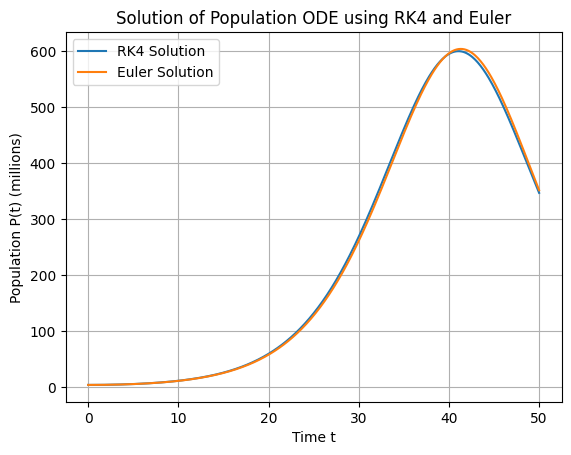

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the ODE function, for example, dy/dt = f(t, y)
# system of equations
def f(t, y):
    # y is a vector [P, v]
    P = y[0]
    v = y[1]

    # system equations from population model
    dPdt = v
    dvdt = r * P - k * P**2

    return np.array([dPdt, dvdt])


# Implement the RK4 method
def runge_kutta_4(f, y0, t0, tf, h):
    # Create an array for time steps
    t_values = np.arange(t0, tf + h, h)

    #  2 variables
    y_values = np.zeros((len(t_values), len(y0)))

    # Set the initial condition
    y_values[0] = y0

    # Perform the RK4 iteration
    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y = y_values[i - 1]

        k1 = h * f(t, y)
        k2 = h * f(t + h / 2, y + k1 / 2)
        k3 = h * f(t + h / 2, y + k2 / 2)
        k4 = h * f(t + h, y + k3)

        # Update y based on the RK4 formula
        y_values[i] = y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

    return t_values, y_values


# euler Forward Method
def euler_forward(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)


    y_values = np.zeros((len(t_values), len(y0)))

    y_values[0] = y0

    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y = y_values[i - 1]

        y_values[i] = y + h * f(t, y)

    return t_values, y_values


# Set initial conditions and parameters
# y0 is now a vector [P, v]
y0 = np.array([P_0, v_0])

t0 = t_start
tf = t_end
h = 0.1

# Run the RK4 solver
t_rk4, y_rk4 = runge_kutta_4(f, y0, t0, tf, h)

# ADDED: Run Euler solver
t_euler, y_euler = euler_forward(f, y0, t0, tf, h)


# Plot the results

plt.plot(t_rk4, y_rk4[:, 0], label='RK4 Solution')
plt.plot(t_euler, y_euler[:, 0], label='Euler Solution')

plt.xlabel('Time t')
plt.ylabel('Population P(t) (millions)')
plt.title('Solution of Population ODE using RK4 and Euler')
plt.legend()
plt.grid(True)
plt.show()

#Section 4 : Solutions & Comparison

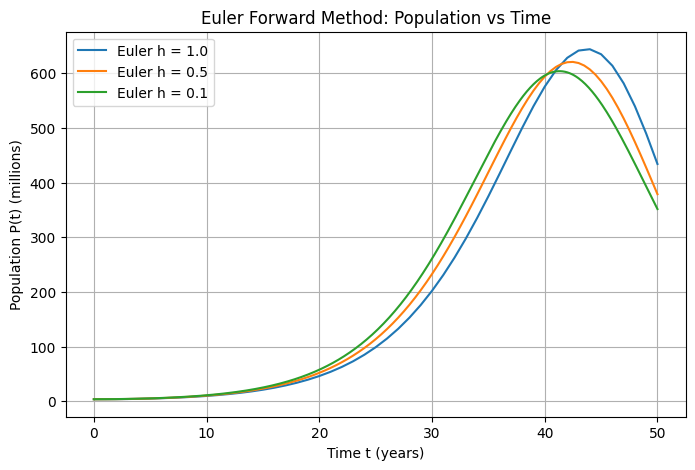

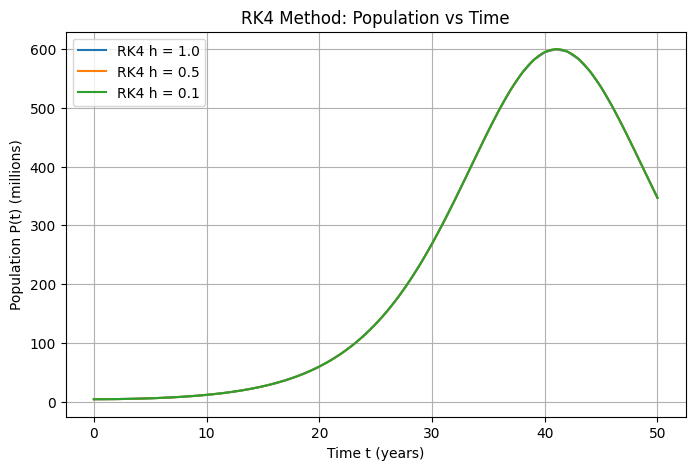

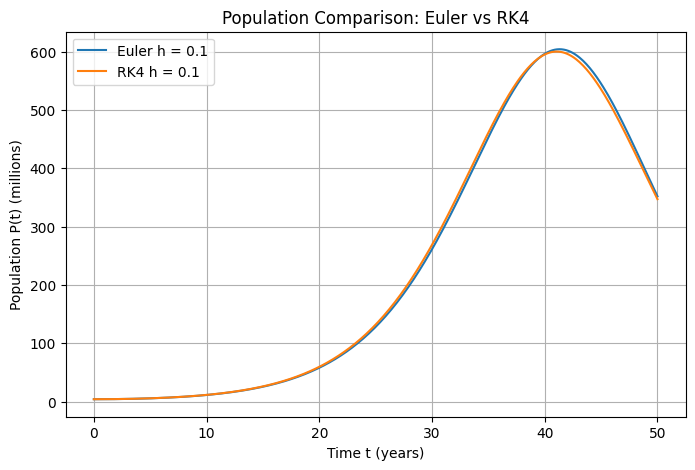

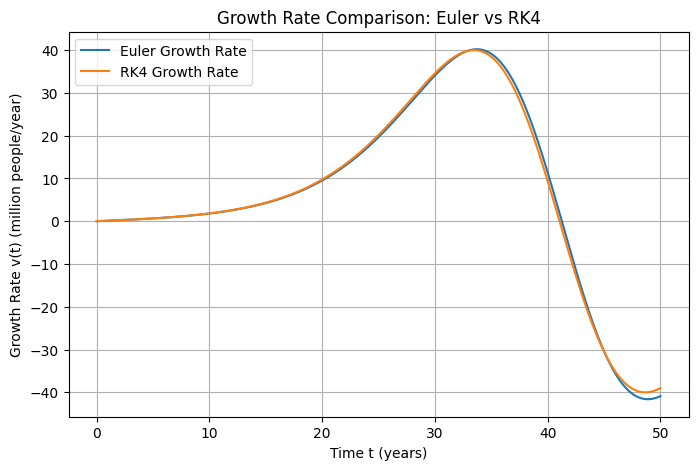

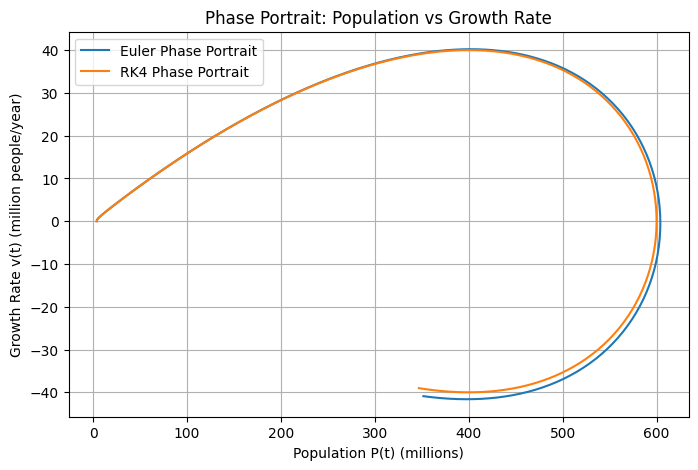

In [ ]:
# Section 4: Solutions & Comparison

# Step sizes to compare
h_values = [1.0, 0.5, 0.1]

euler_results = {}
rk4_results = {}

# Run both methods
for h in h_values:
    t_euler, y_euler = euler_forward(f, y0, t0, tf, h)
    t_rk4, y_rk4 = runge_kutta_4(f, y0, t0, tf, h)

    euler_results[h] = (t_euler, y_euler)
    rk4_results[h] = (t_rk4, y_rk4)


# Population vs time for Euler Method
plt.figure(figsize=(8, 5))

for h in h_values:
    t_euler, y_euler = euler_results[h]
    plt.plot(t_euler, y_euler[:, 0], label=f"Euler h = {h}")

plt.xlabel("Time t (years)")
plt.ylabel("Population P(t) (millions)")
plt.title("Euler Forward Method: Population vs Time")
plt.legend()
plt.grid(True)
plt.show()


# Population vs time for RK4 Method
plt.figure(figsize=(8, 5))

for h in h_values:
    t_rk4, y_rk4 = rk4_results[h]
    plt.plot(t_rk4, y_rk4[:, 0], label=f"RK4 h = {h}")

plt.xlabel("Time t (years)")
plt.ylabel("Population P(t) (millions)")
plt.title("RK4 Method: Population vs Time")
plt.legend()
plt.grid(True)
plt.show()


# Compare Euler and RK4 smallest step size
h_compare = 0.1

t_euler, y_euler = euler_results[h_compare]
t_rk4, y_rk4 = rk4_results[h_compare]

plt.figure(figsize=(8, 5))
plt.plot(t_euler, y_euler[:, 0], label="Euler h = 0.1")
plt.plot(t_rk4, y_rk4[:, 0], label="RK4 h = 0.1")

plt.xlabel("Time t (years)")
plt.ylabel("Population P(t) (millions)")
plt.title("Population Comparison: Euler vs RK4")
plt.legend()
plt.grid(True)
plt.show()


# Velocity/growth rate vs time
plt.figure(figsize=(8, 5))
plt.plot(t_euler, y_euler[:, 1], label="Euler Growth Rate")
plt.plot(t_rk4, y_rk4[:, 1], label="RK4 Growth Rate")

plt.xlabel("Time t (years)")
plt.ylabel("Growth Rate v(t) (million people/year)")
plt.title("Growth Rate Comparison: Euler vs RK4")
plt.legend()
plt.grid(True)
plt.show()


# Phase portrait
plt.figure(figsize=(8, 5))
plt.plot(y_euler[:, 0], y_euler[:, 1], label="Euler Phase Portrait")
plt.plot(y_rk4[:, 0], y_rk4[:, 1], label="RK4 Phase Portrait")

plt.xlabel("Population P(t) (millions)")
plt.ylabel("Growth Rate v(t) (million people/year)")
plt.title("Phase Portrait: Population vs Growth Rate")
plt.legend()
plt.grid(True)
plt.show()

The results from the RK4 Method appear to have more smoothness and stability compared to the ones from Euler’s Method, which contain errors depending on the step sizes. The results from Euler’s Method approach those from RK4 as the step sizes decrease.

The growth rate, \(v(t)\),is plotted over time.

In addition, the population and the growth rate are plotted together in a phase portrait to show how the two variables depend on one another and how the system changes with time.

Unlike the spiral phase plots in a damped system example, the population model does not have any damping term in its equation. The graphs above represent the dependence of population on its growth rate, which appears distorted due to Euler’s Method.

### Section5

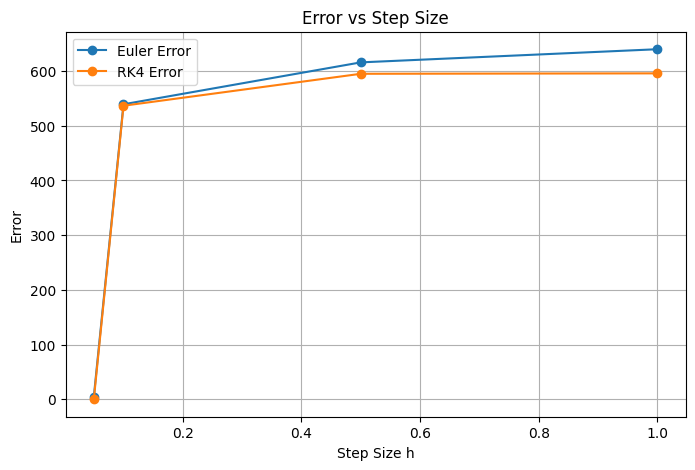

In [ ]:
# Section 5: Stability Analysis

h_values = [1.0, 0.5, 0.1, 0.05]

t_ref, y_ref = runge_kutta_4(f, y0, t0, tf, 0.05)
P_ref = y_ref[:, 0]

errors_euler = []
errors_rk4 = []

for h in h_values:
    t_euler, y_euler = euler_forward(f, y0, t0, tf, h)
    t_rk4, y_rk4 = runge_kutta_4(f, y0, t0, tf, h)

    min_len = min(len(P_ref), len(y_euler), len(y_rk4))

    error_euler = np.max(np.abs(y_euler[:min_len, 0] - P_ref[:min_len]))
    error_rk4 = np.max(np.abs(y_rk4[:min_len, 0] - P_ref[:min_len]))

    errors_euler.append(error_euler)
    errors_rk4.append(error_rk4)


# Plot error vs step size
plt.figure(figsize=(8,5))
plt.plot(h_values, errors_euler, 'o-', label="Euler Error")
plt.plot(h_values, errors_rk4, 'o-', label="RK4 Error")

plt.xlabel("Step Size h")
plt.ylabel("Error")
plt.title("Error vs Step Size")
plt.legend()
plt.grid(True)
plt.show()

The stability and accuracy analysis for Euler’s Method and the RK4 Method are conducted in this section using different step sizes.

With increase in the step size, instability is observed in Euler’s Method and results in errors. This can be clearly observed from the plots generated since there is no matching of solutions. The RK4 Method remains stable and gives smooth solutions with increase in step size.

The reference solution taken for calculating the error using the RK4 method is the solution obtained at \(h = 0.05\). For computing the error, solutions obtained at various stepsizes are compared to the reference solution.

From the plots and the results, it is clear that Euler’s Method is less accurate than RK4 Method in solving differential equations.

From the plots and results generated above, instability is shown by Euler’s Method, and RK4 method remains stable and consistent. From this, it is evident that the RK4 Method is a higher-order numerical scheme.

From the analysis, Euler’s Method can result in unstable solutions, leading to unrealistic population dynamics.

## Section 6 – Conclusions

The Population Dynamics Model was solved using Euler’s Method and the RK4 Method. The outcome of this exercise shows that RK4 is more accurate and stable than Euler’s Method, especially when dealing with larger steps.

The Euler’s Method is simpler to use and compute, but generates bigger error and might be unstable when using larger steps. On the other hand, while being somewhat more expensive to compute, RK4 is much more accurate and generates smoother results.

The analysis of these methods also revealed that decreasing the step size leads to increased accuracy in both algorithms, but RK4 still performs well with larger steps.

In conclusion, the RK4 method should be used when working on the problem presented above, as it offers the best combination of efficiency and reliability.